#Классификация изображений


##Загрузка датасета
Для работы был выбран датасет с исскуственно созданными портретами людей. Задача - определить пол человека по изображению. Выбор датасета оправдан его практической применимостью в системах автоматической обработки изображений (например, в маркетинговой аналитике или пользовательской персонализации), при этом использование искусственно сгенерированных данных позволяет избежать проблем с приватностью и юридическими ограничениями, связанных с реальными изображениями людей.

In [ ]:
!kaggle datasets download hosseinbadrnezhad/human-faces-dataset-male-female-classification

Dataset URL: https://www.kaggle.com/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification
License(s): apache-2.0
human-faces-dataset-male-female-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip human-faces-dataset-male-female-classification.zip -d faces

##Метрики качества
Для оценки качества модели будем использовать следующие метрики качества классификации.
- accuracy
- f1
- ROC-AUC

Эти метрики являются стандартными в оценке качества моделей клссификации. Основно метрикой является f1 так как она обобщает метрики precision и recall/

##Импорт библиотек

In [ ]:
import os
import random
import shutil
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.optim import Adam

import torchvision
from torchvision import  datasets
from torchvision import  transforms
from torchvision.transforms import ToTensor

from torchvision.models import resnet18, ResNet18_Weights, vit_b_16, ViT_B_16_Weights

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [ ]:
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


##Подготовка данных


In [ ]:
# Разпределяем датасет на train test
train_split = 0.70
test_split = 0.30

source_dir = "faces"
target_dir = "faces_dataset"

for split in ["train", "test"]:
    for class_name in os.listdir(source_dir):
        os.makedirs(os.path.join(target_dir, split, class_name), exist_ok = True)

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    images = os.listdir(class_path)

    random.shuffle(images)

    n = len(images)
    train_start, train_end = 0, int(n * train_split)
    test_start,  test_end = train_end, n

    train_images = images[train_start : train_end]
    test_images  = images[test_start  : test_end]

    for image in train_images:
        shutil.copy(
            os.path.join(class_path, image),
            os.path.join(target_dir, "train", class_name, image)
        )

    for image in test_images:
        shutil.copy(
            os.path.join(class_path, image),
            os.path.join(target_dir, "test", class_name, image)
        )



train_dir = os.path.join(target_dir, "train")
test_dir = os.path.join(target_dir, "test")
dataset_dir = target_dir

Примеры изображений в датасете

(1024, 1024)
(1024, 1024)


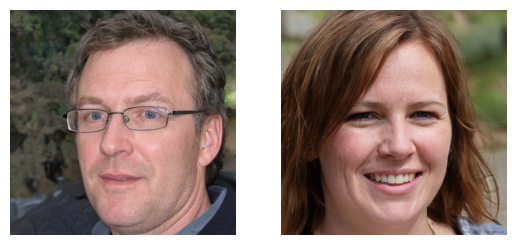

In [ ]:
random_man_path = random.choice(os.listdir("faces/men", ))
random_woman_path = random.choice(os.listdir("faces/women"))

random_man = Image.open(os.path.join("faces/men", random_man_path))
random_woman = Image.open(os.path.join("faces/women", random_woman_path))

fig,ax = plt.subplots(1,2)

ax[0].imshow(random_man)
ax[0].axis('off')
print(random_man.size)
ax[1].imshow(random_woman)
ax[1].axis('off')
print(random_woman.size)

In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

train_data = datasets.ImageFolder(root = os.path.join(dataset_dir, "train"),
                                  transform = data_transform,
                                  target_transform=None)


test_data = datasets.ImageFolder(root = os.path.join(dataset_dir, "test"),
                                  transform = data_transform,
                                  target_transform=None)




BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True)

###Функции обучения и оценки

In [ ]:
def train(model, epochs, dataloader, optimizer, criterion):
    for epoch in range(epochs):
        model.train()

        for images, labels in dataloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"epoch {epoch + 1}")


def eval(model, dataloader):
    model.to(DEVICE)
    model.eval()

    pred = []
    probs = []
    ground_truth = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            pred_classes = outputs.argmax(dim=1)
            prob_classes = torch.softmax(outputs, dim=1)[:, 1]

            pred.extend(pred_classes.cpu().tolist())
            probs.extend(prob_classes.cpu().tolist())
            ground_truth.extend(labels.cpu().tolist())

    accuracy = accuracy_score(ground_truth, pred)
    f1 = f1_score(ground_truth, pred)
    roc_auc = roc_auc_score(ground_truth, probs)

    print(f"accuracy score: {accuracy}")
    print(f"f1 score: {f1}")
    print(f"ROC-AUC: {roc_auc}")

    return accuracy, f1, roc_auc

##Бейзлайн

###ResNet

In [ ]:
resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
resnet.to(DEVICE)
resnet.fc = nn.Linear(resnet.fc.in_features, 2).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(resnet.parameters(), lr=1e-3)


train(resnet, 5, train_dataloader, optimizer, criterion)


epoch 1
epoch 2
epoch 3
epoch 4
epoch 5


In [ ]:
eval(resnet, test_dataloader)

accuracy score: 0.9907866761162296
f1 score: 0.9926428975664969
ROC-AUC: 0.9996570777019063


(0.9907866761162296, 0.9926428975664969, np.float64(0.9996570777019063))

###ViT

In [ ]:
vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
vit.to(DEVICE)
vit.heads.head = nn.Linear(vit.heads.head.in_features, 2).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(vit.parameters(), lr=1e-3)


train(vit, 5, train_dataloader, optimizer, criterion)


epoch 1
epoch 2
epoch 3
epoch 4
epoch 5


In [ ]:
eval(vit, test_dataloader)

accuracy score: 0.6250885896527285
f1 score: 0.7692978630614915
ROC-AUC: 0.6077954811414168


(0.6250885896527285, 0.7692978630614915, np.float64(0.6077954811414168))

###Подготовка данных

##Улучшение бейзлайна

Гипотезы
- Аугментация данных
- Увеличение числа эпох в обучении


####Аугментация данных

In [ ]:
augmented_data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.RandomResizedCrop(224),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

augmented_train_data = datasets.ImageFolder(root = os.path.join(dataset_dir, "train"),
                                  transform = augmented_data_transform,
                                  target_transform=None)


augmented_train_dataloader = DataLoader(dataset=augmented_train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True)

In [ ]:
augmented_resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
augmented_resnet.to(DEVICE)
augmented_resnet.fc = nn.Linear(augmented_resnet.fc.in_features, 2).to(DEVICE)

optimizer = Adam(augmented_resnet.parameters(), lr=1e-3)

train(augmented_resnet, 5, augmented_train_dataloader, optimizer, criterion)

epoch 1
epoch 2
epoch 3
epoch 4
epoch 5


In [ ]:
eval(augmented_resnet, test_dataloader)

accuracy score: 0.8802267895109851
f1 score: 0.9124805800103574
ROC-AUC: 0.9908846966637946


(0.8802267895109851, 0.9124805800103574, np.float64(0.9908846966637946))

In [ ]:
augmented_vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
augmented_vit.to(DEVICE)
augmented_vit.heads.head = nn.Linear(augmented_vit.heads.head.in_features, 2).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(augmented_vit.parameters(), lr=1e-3)

train(augmented_vit, 5, augmented_train_dataloader, optimizer, criterion)

epoch 1
epoch 2
epoch 3
epoch 4
epoch 5


In [ ]:
eval(augmented_vit, test_dataloader)

accuracy score: 0.6250885896527285
f1 score: 0.7692978630614915
ROC-AUC: 0.5899270861463678


(0.6250885896527285, 0.7692978630614915, np.float64(0.5899270861463678))

####Увеличение количества эпох

In [ ]:
epochs_resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
epochs_resnet.to(DEVICE)
epochs_resnet.fc = nn.Linear(epochs_resnet.fc.in_features, 2).to(DEVICE)

optimizer = Adam(epochs_resnet.parameters(), lr=1e-3)

train(epochs_resnet, 10, train_dataloader, optimizer, criterion)

epoch 1
epoch 2
epoch 3
epoch 4
epoch 5
epoch 6
epoch 7
epoch 8
epoch 9
epoch 10


In [ ]:
eval(epochs_resnet, test_dataloader)

accuracy score: 0.9879518072289156
f1 score: 0.9902690326273612
ROC-AUC: 0.9999442751265597


(0.9879518072289156, 0.9902690326273612, np.float64(0.9999442751265597))

In [ ]:
epochs_vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
epochs_vit.to(DEVICE)
epochs_vit.heads.head = nn.Linear(epochs_vit.heads.head.in_features, 2).to(DEVICE)

optimizer = Adam(epochs_vit.parameters(), lr=1e-3)

train(epochs_vit, 10, train_dataloader, optimizer, criterion)

epoch 1
epoch 2
epoch 3
epoch 4
epoch 5
epoch 6
epoch 7
epoch 8
epoch 9
epoch 10


In [ ]:
eval(epochs_vit, test_dataloader)

accuracy score: 0.6250885896527285
f1 score: 0.7692978630614915
ROC-AUC: 0.7545297892313826


(0.6250885896527285, 0.7692978630614915, np.float64(0.7545297892313826))

####Вывод
Аугментация данных привела к ухудшению качества модели. Это можно объяснить тем, что датасет сенерирован искусственно и содержит  однообразные изображения с минимальной вариацией и аугментация данных добавляет вариации, которых не существует в тестовом датасете.\
Увеличение количества эпох обучения позволило моделям лучше обучиться на данных и показать лучший результат на тестовых данных

##Собственная имплементация

###ResNet

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=(3, 3),stride=1, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=(3, 3),stride=1, padding=1),
            nn.BatchNorm2d(channels),
            )
        self.relu =nn.ReLU()
    def forward(self, x):
        x = x + self.block(x)
        x = self.relu(x)
        return x

class CustomResNet(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer1 = ResBlock(32)

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer2 = ResBlock(64)

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer3 = ResBlock(128)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)

        x = self.conv2(x)
        x = self.layer2(x)

        x = self.conv3(x)
        x = self.layer3(x)

        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)

        return x

In [ ]:
custom_resnet = CustomResNet()
custom_resnet = custom_resnet.to(DEVICE)

optimizer = Adam(custom_resnet.parameters(), lr=1e-3)

train(custom_resnet, 5, train_dataloader, optimizer, criterion)

epoch 1
epoch 2
epoch 3
epoch 4
epoch 5


In [ ]:
eval(custom_resnet, train_dataloader)

accuracy score: 0.9464375947448206
f1 score: 0.9576
ROC-AUC: 0.9886308761237373


(0.9464375947448206, 0.9576, np.float64(0.9886308761237373))

###ViT

In [ ]:
import torch
import torch.nn as nn


class Attention(nn.Module):
    def __init__(self, dim, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x):
        out, _ = self.attn(x, x, x)
        return out


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads, mlp_dim, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, n_heads, dropout)

        self.norm2 = nn.LayerNorm(dim)
        self.ff = FeedForward(dim, mlp_dim, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


class CustomViT(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        emb_dim=256,
        n_heads=8,
        depth=4,
        mlp_dim=512,
        num_classes=2,
        dropout=0.1,
    ):
        super().__init__()

        self.patch_embed = nn.Conv2d(
            in_channels=3,
            out_channels=emb_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        num_patches = (img_size // patch_size) ** 2

        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))

        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            TransformerBlock(emb_dim, n_heads, mlp_dim, dropout)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(emb_dim)

        self.head = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]

        x = self.patch_embed(x)

        x = x.flatten(2)
        x = x.transpose(1, 2)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embedding

        x = self.dropout(x)

        x = self.blocks(x)

        x = self.norm(x)

        cls = x[:, 0]

        out = self.head(cls)

        return out

In [ ]:
custom_ViT = CustomViT()
custom_ViT.to(DEVICE)

optimizer = Adam(custom_ViT.parameters(), lr=1e-3)

train(custom_ViT, 5, train_dataloader, optimizer, criterion)

epoch 1
epoch 2
epoch 3
epoch 4
epoch 5


In [ ]:
eval(custom_ViT, test_dataloader)

accuracy score: 0.8639262934089298
f1 score: 0.8917700112739572
ROC-AUC: 0.9376845886432709


(0.8639262934089298, 0.8917700112739572, np.float64(0.9376845886432709))

### Применение гипотез по улучшению к каcтомным моделям

In [ ]:
optimizer = Adam(custom_resnet.parameters(), lr=1e-3)

train(custom_resnet, 10, train_dataloader, optimizer, criterion)

epoch 1
epoch 2
epoch 3
epoch 4
epoch 5
epoch 6
epoch 7
epoch 8
epoch 9
epoch 10


In [ ]:
eval(custom_resnet, test_dataloader)

accuracy score: 0.9794472005669738
f1 score: 0.9835320840431573
ROC-AUC: 0.9976959908096825


(0.9794472005669738, 0.9835320840431573, np.float64(0.9976959908096825))

In [ ]:
optimizer = Adam(custom_ViT.parameters(), lr=1e-3)

train(custom_ViT, 10, train_dataloader, optimizer, criterion)

epoch 1
epoch 2
epoch 3
epoch 4
epoch 5
epoch 6
epoch 7
epoch 8
epoch 9
epoch 10


In [ ]:
eval(custom_ViT, test_dataloader)

accuracy score: 0.9255846917080085
f1 score: 0.9420849420849421
ROC-AUC: 0.983623317001659


(0.9255846917080085, 0.9420849420849421, np.float64(0.983623317001659))

##Выводы
|#| accuracy | f1 score | ROC AUC  
|---|---|---|---|
| ResNet | 0.9869 | 0.9903 | 0.9999
| ViT | 0.6251 | 0.7693 | 0.7545
| custom ResNet| 0.9795 | 0.9835 | 0.9977
| custom ViT | 0.9255 | 0.9421 | 0.9836

Полученные результаты показывают, что модели на основе сверточных нейронных сетей демонстрируют наилучшее качество на данном наборе данных. ResNet значительно превосходит остальные модели по всем метрикам, что указывает на его высокую способность извлекать пространственные признаки даже при относительно небольшом объеме данных. В то же время базовая модель Vision Transformer показывает существенно более низкие результаты, что связано с её высокой сложностью и требовательностью к объему обучающей выборки. При этом кастомная реализация трансформера демонстрирует значительное улучшение по сравнению с базовой версией, что подтверждает важность подбора архитектуры под конкретную задачу и размер данных. В целом, результаты подтверждают, что для данной задачи наиболее эффективными являются компактные и хорошо адаптированные модели, тогда как более сложные архитектуры требуют дополнительных настроек и большего объема данных.